In [2]:
import sys
import pandas as pd
import xml.etree.ElementTree as ET
from pathlib import Path

ROOT = Path.cwd().parent.parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

import scripts.src.inputs.config as cfg
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from collections import Counter
import re

log = "/home/fullsuper/irene/sumo_run.log"
veh_teleport_count = Counter()
with open(log, encoding="utf-8", errors="ignore") as f:
    for line in f:
        if "Teleporting vehicle" in line:
            m = re.search(r"Teleporting vehicle '([^']+)'", line)
            if m:
                veh_teleport_count[m.group(1)] += 1

print("Veicoli teletrasportati più volte:")
for vid, count in veh_teleport_count.most_common(20):
    print(f"  {vid}: {count} volte")

Veicoli teletrasportati più volte:
  13183: 12 volte
  10696: 11 volte
  14106: 10 volte
  14118: 10 volte
  27820: 10 volte
  10205: 10 volte
  10368: 10 volte
  15560: 10 volte
  13182: 10 volte
  13013: 10 volte
  14325: 10 volte
  14979: 10 volte
  10327: 9 volte
  12962: 9 volte
  17870: 9 volte
  15585: 9 volte
  15604: 9 volte
  14671: 9 volte
  10716: 9 volte
  14275: 9 volte


In [7]:
pattern = re.compile(r"Teleporting vehicle '13183'.*?lane='([^']+)'")
with open(log, encoding="utf-8", errors="ignore") as f:
    for line in f:
        m = pattern.search(line)
        if m:
            print(m.group(1))

-59619002_0
1113770110#2_2
1113770112#0_2
1113770113#1_1
1113770114#3_1
154986388#1_0
121952561#0_0
121952561#1_0
121952561#2_2
81240118_0
:943582684_0_0
81240119_0


In [8]:
import sumolib

net = sumolib.net.readNet(cfg.NET_FILE)

for street_base in ["1113770110", "1113770112", "1113770113", "1113770114",
                     "121952561", "154986388", "81240118", "81240119"]:
    edges = [e for e in net.getEdges() if e.getID().lstrip("-").split("#")[0] == street_base]
    for e in edges:
        print(f"{e.getID()}: numLanes={e.getLaneNumber()}, speed={e.getSpeed():.1f}, priority={e.getPriority()}")

1113770110#0: numLanes=3, speed=19.4, priority=11
1113770110#1: numLanes=3, speed=19.4, priority=11
1113770110#2: numLanes=3, speed=19.4, priority=11
1113770112#0: numLanes=3, speed=19.4, priority=11
1113770112#1: numLanes=3, speed=19.4, priority=11
1113770112#2: numLanes=3, speed=19.4, priority=11
1113770113#0: numLanes=3, speed=19.4, priority=11
1113770113#1: numLanes=3, speed=19.4, priority=11
1113770114#0: numLanes=4, speed=19.4, priority=11
1113770114#1: numLanes=4, speed=19.4, priority=11
1113770114#2: numLanes=4, speed=19.4, priority=11
1113770114#3: numLanes=4, speed=19.4, priority=11
121952561#0: numLanes=3, speed=19.4, priority=11
121952561#1: numLanes=3, speed=19.4, priority=11
121952561#2: numLanes=3, speed=19.4, priority=11
121952561#3: numLanes=3, speed=19.4, priority=11
154986388#0: numLanes=3, speed=19.4, priority=11
154986388#1: numLanes=3, speed=19.4, priority=11
154986388#2: numLanes=3, speed=19.4, priority=11
154986388#3: numLanes=3, speed=19.4, priority=11
81240118

In [28]:
import xml.etree.ElementTree as ET

def select_route_element(veh):
    route_el = veh.find("route")
    if route_el is not None:
        return route_el
    route_dist = veh.find("routeDistribution")
    if route_dist is not None:
        routes = route_dist.findall("route")
        if not routes:
            return None
        if len(routes) == 1:
            return routes[0]
        def route_key(r):
            prob = float(r.get("probability", 0) or 0)
            cost = float(r.get("cost", "inf") or "inf")
            return (-prob, cost)
        return sorted(routes, key=route_key)[0]
    return None

tree = ET.parse("/home/fullsuper/irene/dtSumo/scripts/output/marouter-workdir/MA_no_TLS_AM/marouter_output_clean.rou.xml")  # verifica sia il file giusto
root = tree.getroot()

top_level_routes = {
    r.get("id"): r.get("edges", "").split()
    for r in root.findall("route") if r.get("id") is not None
}

arterial_edges = {"1113770110#0","1113770110#1","1113770110#2","1113770112#0","1113770112#1","1113770112#2",
                   "1113770113#0","1113770113#1","1113770114#0","1113770114#1","1113770114#2","1113770114#3",
                   "121952561#0","121952561#1","121952561#2","121952561#3",
                   "154986388#0","154986388#1","154986388#2","154986388#3"}
funnel_edges = {"81240118", "81240119"}

count_via_arterial = 0
count_ending_residential = 0
n_total = 0
n_no_route = 0

for veh in root.findall("vehicle") + root.findall("trip"):
    n_total += 1
    route_el = select_route_element(veh)
    edges = None
    if route_el is not None:
        edges = route_el.get("edges", "").split()
    else:
        ref = veh.get("route")
        if ref in top_level_routes:
            edges = top_level_routes[ref]

    if not edges:
        n_no_route += 1
        continue

    if arterial_edges & set(edges):
        count_via_arterial += 1
        if edges[-1] in funnel_edges:
            count_ending_residential += 1

print(f"Veicoli totali nel file: {n_total}")
print(f"Veicoli senza route trovata: {n_no_route}")
print(f"Veicoli sull'arteria: {count_via_arterial}")
if count_via_arterial > 0:
    print(f"Di questi, con destinazione nell'imbuto: {count_ending_residential} "
          f"({count_ending_residential/count_via_arterial:.1%})")
else:
    print("Nessun veicolo trovato sull'arteria — controlla il file/gli id sotto")
    # stampa qualche route a campione per confronto manuale
    for veh in root.findall("vehicle")[:3]:
        route_el = select_route_element(veh)
        if route_el is not None:
            print(veh.get("id"), route_el.get("edges", "")[:200])

Veicoli totali nel file: 27587
Veicoli senza route trovata: 0
Veicoli sull'arteria: 2174
Di questi, con destinazione nell'imbuto: 0 (0.0%)


In [ ]:
import xml.etree.ElementTree as ET
tree = ET.parse("/home/fullsuper/irene/dtSumo/scripts/output/marouter-workdir/MA_no_TLS_AM/marouter_output_extended.rou.xml")
root = tree.getroot()

n_single_alt = 0
n_multi_alt = 0
n_no_dist = 0

for veh in root.findall("vehicle") + root.findall("trip"):
    rd = veh.find("routeDistribution")
    if rd is None:
        if veh.find("route") is not None:
            n_no_dist += 1
        continue
    n_alt = len(rd.findall("route"))
    if n_alt <= 1:
        n_single_alt += 1
    else:
        n_multi_alt += 1

total = n_single_alt + n_multi_alt + n_no_dist
print(f"Veicoli totali con route: {total}")
print(f"Con 1 sola alternativa: {n_single_alt} ({n_single_alt/total:.1%})")
print(f"Con >1 alternative: {n_multi_alt} ({n_multi_alt/total:.1%})")
print(f"Senza routeDistribution (route diretta): {n_no_dist}")

Veicoli totali con route: 27587
Con 1 sola alternativa: 0 (0.0%)
Con >1 alternative: 27587 (100.0%)
Senza routeDistribution (route diretta): 0


In [16]:
count_via_funnel = 0

for veh in root.findall("vehicle") + root.findall("trip"):
    route_el = select_route_element(veh)
    edges = None
    if route_el is not None:
        edges = route_el.get("edges", "").split()
    else:
        ref = veh.get("route")
        if ref in top_level_routes:
            edges = top_level_routes[ref]
    if not edges:
        continue
    if funnel_edges & set(edges):
        count_via_funnel += 1

print(f"Veicoli che ATTRAVERSANO l'imbuto (81240118/119), ovunque nella route: {count_via_funnel}")

Veicoli che ATTRAVERSANO l'imbuto (81240118/119), ovunque nella route: 438


In [3]:
tripinfo_am  = Path("/home/fullsuper/irene/dtSumo/scripts/output/simulation-out/out_MA_no_TLS/TripInfo_marouter_AM.xml")

tree = ET.parse(tripinfo_am)
root = tree.getroot()

info = []

for trip in root.findall("tripinfo"):
    info.append(
    {"id": float(trip.get("id")),
    "depart": float(trip.get("depart")),
    "departLane": str(trip.get("departLane")),
    "departPos": float(trip.get("departPos")),
    "arrival": float(trip.get("arrival")),
    "arrivalLane": str(trip.get("arrivalLane")),
    "arrivalPos": float(trip.get("arrivalPos")),
    "duration": float(trip.get("duration")),
    "routeLength": float(trip.get("routeLength")),
    "waitingTime": float(trip.get("waitingTime")),
    "timeLoss": float(trip.get("timeLoss")),
    })
    
df_res = pd.DataFrame(info)
df_res

,id,depart,departLane,departPos,arrival,arrivalLane,arrivalPos,duration,routeLength,waitingTime,timeLoss
0,9284.0,28810.0,-323978917#1_0,0.39,28818.0,-418320704_0,0.20,8.0,33.95,0.0,5.27
1,21493.0,28817.0,-1307179610#0_0,0.20,28821.0,-659342821_0,0.20,4.0,14.38,0.0,3.21
2,2046.0,28819.0,172346038#3_0,5.10,28822.0,172346038#4_0,13.77,3.0,30.56,0.0,0.18
3,604.0,28809.0,1305781749_2,5.10,28823.0,48998342#2_0,21.20,14.0,210.23,0.0,3.39
4,9478.0,28824.0,-323978917#1_0,0.39,28826.0,-134572343_0,0.20,2.0,15.10,0.0,0.10
...,...,...,...,...,...,...,...,...,...,...,...
27582,22199.0,83125.0,1307179611#3_0,0.20,83182.0,134572330#2_0,428.72,57.0,491.42,21.0,34.75
27583,22661.0,83096.0,1307179611#3_0,0.20,83184.0,38081508#3_0,85.11,88.0,484.64,22.0,44.17
27584,22662.0,83110.0,1307179611#3_0,0.20,83187.0,1167094068#5_0,86.12,77.0,365.26,25.0,42.08
27585,22663.0,83139.0,1307179611#3_0,0.20,83281.0,678628383#0_0,5.66,142.0,1408.99,22.0,47.30


In [5]:
df = pd.DataFrame(info).sort_values("arrival", ascending=False)
print("Ultimi 20 veicoli ad arrivare:")
print(df.head(20)[["id", "depart", "duration", "routeLength"]])

Ultimi 20 veicoli ad arrivare:
            id   depart  duration  routeLength
27586  22021.0  83053.0     370.0       195.03
27585  22663.0  83139.0     142.0      1408.99
27584  22662.0  83110.0      77.0       365.26
27583  22661.0  83096.0      88.0       484.64
27582  22199.0  83125.0      57.0       491.42
27581  22660.0  83083.0      78.0       365.26
27580  22198.0  83067.0      61.0       491.42
27579  22659.0  83040.0      79.0       484.64
27578  22655.0  82968.0     147.0      1416.22
27577  22019.0  82592.0     518.0       195.03
27576  22657.0  83012.0      92.0       484.64
27575  22658.0  83026.0      73.0       365.26
27574  22656.0  82984.0      88.0       484.64
27573  22653.0  82925.0     134.0      1408.99
27572  22197.0  82998.0      60.0       491.42
27571  22654.0  82939.0      77.0       365.26
27570  22196.0  82953.0      61.0       491.42
27569  22649.0  82856.0     133.0      1408.99
27568  22652.0  82911.0      77.0       365.26
27567  22651.0  82886.0      

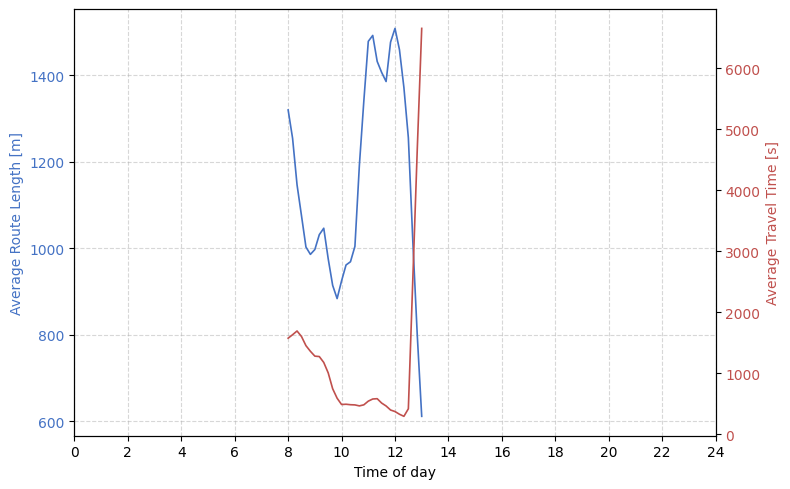

In [ ]:
bin_size_min = 10
df_res["bin"] = (df_res["depart"] // (bin_size_min * 60)) * (bin_size_min * 60)

binned = df_res.groupby("bin").agg(
    avg_length=("routeLength", "mean"),
    avg_duration=("duration", "mean"),
).reset_index()
binned["hour"] = binned["bin"] / 3600.0

window = 3
binned["avg_length_smooth"] = binned["avg_length"].rolling(window, center=True, min_periods=1).mean()
binned["avg_duration_smooth"] = binned["avg_duration"].rolling(window, center=True, min_periods=1).mean()

fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

ax1.plot(binned["hour"], binned["avg_length_smooth"], color="#4472C4", linewidth=1.2)
ax2.plot(binned["hour"], binned["avg_duration_smooth"], color="#C0504D", linewidth=1.2)

ax1.set_xlabel("Time of day")
ax1.set_ylabel("Average Route Length [m]", color="#4472C4")
ax2.set_ylabel("Average Travel Time [s]", color="#C0504D")
ax1.tick_params(axis="y", labelcolor="#4472C4")
ax2.tick_params(axis="y", labelcolor="#C0504D")

ax1.set_xlim(0, 24)
ax1.set_xticks(range(0, 25, 2))
ax1.grid(True, linestyle="--", alpha=0.5)

fig.tight_layout()
plt.savefig("route_length_vs_travel_time.png", dpi=150)
plt.show()

In [15]:
print(df_res['duration'].describe())
print(df_res['duration'].quantile([0.5, 0.9, 0.95, 0.99]))

count    27587.000000
mean      1117.166745
std       1591.512659
min          1.000000
25%        104.000000
50%        345.000000
75%       1544.000000
max      12580.000000
Name: duration, dtype: float64
0.50     345.00
0.90    3358.40
0.95    4617.70
0.99    6870.42
Name: duration, dtype: float64


In [16]:
tail99 = df_res[df_res["duration"] >= df_res["duration"].quantile(0.99)]
print(tail99[["id", "depart", "duration", "routeLength", "waitingTime"]].sort_values("duration", ascending=False).head(20))

            id   depart  duration  routeLength  waitingTime
25488  16951.0  29369.0   12580.0      3162.57      11069.0
25194  16016.0  30180.0   11335.0      2298.41       9980.0
23945  16946.0  29323.0   10933.0      3222.67       9298.0
24561  16007.0  29944.0   10870.0      2638.85       9518.0
23742  16943.0  29296.0   10819.0      3228.01       9184.0
23732  15983.0  29313.0   10793.0      3623.58       9507.0
23666  16950.0  29360.0   10707.0      3232.08       9178.0
23509  17332.0  29359.0   10578.0      3305.17       9361.0
23049  16949.0  29350.0   10251.0      3222.54       8678.0
22732  15979.0  29208.0   10220.0      2969.95       9056.0
22675  22889.0  29250.0   10144.0      2932.57       8931.0
22331  16931.0  29187.0   10011.0      3359.26       8794.0
23756  17035.0  30132.0    9989.0      2368.22       8752.0
22539  16952.0  29378.0    9937.0      3156.60       8653.0
22676  15991.0  29523.0    9871.0      2724.20       8556.0
22047  16160.0  29160.0    9861.0      2

In [17]:
import geopandas as gpd
edges = ET.parse(cfg.EDG_PARSE_XML).getroot()

edges_data = {}

for e in edges.findall("edge"):
    if e.attrib.get("function") == "internal":
        continue
    eid = e.get("id")
    fid = e.get("from")
    tid = e.get("to")
    type_e = e.get("type")
    
    for lane in e.findall("lane"):
        lid = lane.get("id")
        lane_index = lane.attrib.get("index")
        length = lane.attrib.get("length")
        speed = lane.attrib.get("speed")
        l_shape = lane.attrib.get("shape")
        
        lane_data = {
            "id_edge": eid,
            "index": lane_index,
            "from": fid,
            "to": tid,
            "name": e.attrib.get("name", ""),
            "numLanes": e.attrib.get("numLanes", ""),
            "speed": speed,
            "length": length,
            "shape": l_shape,
        }

        # key = lane_id, value = lane_data
        edges_data[lid] = lane_data
        
df_lanes = pd.DataFrame.from_dict(edges_data, orient="index")
df_lanes

,id_edge,index,from,to,name,numLanes,speed,length,shape
-104183437_0,-104183437,0,2939596349,1202156217,,1,5.56,18.37,"7.623217640335089,45.06872643196363 7.62299753..."
-104183444_0,-104183444,0,1202156207,1202156215,,1,5.56,23.25,"7.623302990639859,45.06856830884287 7.62302589..."
-104183448_0,-104183448,0,1202156188,1202156183,,1,5.56,12.43,"7.623143696786155,45.06886974953819 7.62299469..."
-1062120746_0,-1062120746,0,9757569402,9757569401,,1,5.56,21.56,"7.614825673615891,45.06806070418173 7.61508745..."
-106837756_0,-106837756,0,943583045,1228515532,Via Chambery,1,13.89,88.77,"7.615166861007469,45.06895017167228 7.61523946..."
...,...,...,...,...,...,...,...,...,...
952537916#1_0,952537916#1,0,8816346176,8816346175,,1,5.56,23.45,"7.632929026250044,45.07311663538644 7.63294093..."
952537916#2_0,952537916#2,0,8816346175,8816346171,,1,5.56,28.96,"7.633132621479613,45.07299088687306 7.63315283..."
99754717#0_0,99754717#0,0,1153150681,1153150653,Via Onorato Castellino,1,13.89,87.87,"7.63195602791404,45.06977286982974 7.631733851..."
99754717#1_0,99754717#1,0,1153150653,1153150688,Via Onorato Castellino,1,13.89,143.4,"7.631429941346878,45.06893371731799 7.63092902..."


In [ ]:
usage_depart = df_res.groupby("departLane").size().rename("n_inserted").reset_index()
usage_arrival = df_res.groupby("arrivalLane").size().rename("n_inserted").reset_index()
usage_depart

,departLane,n_inserted
0,-110531712#0_0,5
1,-110531712#1_0,5
2,-110531715_0,6
3,-111859620#0_0,5
4,-111859620#1_0,3
...,...,...
1130,952537916#1_0,15
1131,952537916#2_0,15
1132,99754717#0_0,9
1133,99754717#1_0,13


In [19]:
from shapely import LineString

df_lanes['geometry'] = df_lanes["shape"].apply(
        lambda shape: LineString(
                [tuple(map(float, coord.split(","))) for coord in shape.split()]
        )
)

gdf_lanes = gpd.GeoDataFrame(df_lanes, geometry="geometry", crs="EPSG:32632")
gdf_lanes = gdf_lanes.reset_index().rename(columns={"level_0": "lane_id"})

gdf_lanes

,lane_id,id_edge,index,from,to,name,numLanes,speed,length,shape,geometry
0,-104183437_0,-104183437,0,2939596349,1202156217,,1,5.56,18.37,"7.623217640335089,45.06872643196363 7.62299753...","LINESTRING (7.623 45.069, 7.623 45.069)"
1,-104183444_0,-104183444,0,1202156207,1202156215,,1,5.56,23.25,"7.623302990639859,45.06856830884287 7.62302589...","LINESTRING (7.623 45.069, 7.623 45.068)"
2,-104183448_0,-104183448,0,1202156188,1202156183,,1,5.56,12.43,"7.623143696786155,45.06886974953819 7.62299469...","LINESTRING (7.623 45.069, 7.623 45.069)"
3,-1062120746_0,-1062120746,0,9757569402,9757569401,,1,5.56,21.56,"7.614825673615891,45.06806070418173 7.61508745...","LINESTRING (7.615 45.068, 7.615 45.068)"
4,-106837756_0,-106837756,0,943583045,1228515532,Via Chambery,1,13.89,88.77,"7.615166861007469,45.06895017167228 7.61523946...","LINESTRING (7.615 45.069, 7.615 45.068)"
...,...,...,...,...,...,...,...,...,...,...,...
3485,952537916#1_0,952537916#1,0,8816346176,8816346175,,1,5.56,23.45,"7.632929026250044,45.07311663538644 7.63294093...","LINESTRING (7.633 45.073, 7.633 45.073, 7.633 ..."
3486,952537916#2_0,952537916#2,0,8816346175,8816346171,,1,5.56,28.96,"7.633132621479613,45.07299088687306 7.63315283...","LINESTRING (7.633 45.073, 7.633 45.073, 7.633 ..."
3487,99754717#0_0,99754717#0,0,1153150681,1153150653,Via Onorato Castellino,1,13.89,87.87,"7.63195602791404,45.06977286982974 7.631733851...","LINESTRING (7.632 45.07, 7.632 45.069, 7.632 4..."
3488,99754717#1_0,99754717#1,0,1153150653,1153150688,Via Onorato Castellino,1,13.89,143.4,"7.631429941346878,45.06893371731799 7.63092902...","LINESTRING (7.631 45.069, 7.631 45.068, 7.631 ..."


In [20]:
gdf_usage_depart = gdf_lanes.merge(usage_depart, left_on="lane_id", right_on="departLane", how="left")
gdf_usage_depart["n_inserted"] = gdf_usage_depart["n_inserted"].fillna(0)

gdf_usage_depart

,lane_id,id_edge,index,from,to,name,numLanes,speed,length,shape,geometry,departLane,n_inserted
0,-104183437_0,-104183437,0,2939596349,1202156217,,1,5.56,18.37,"7.623217640335089,45.06872643196363 7.62299753...","LINESTRING (7.623 45.069, 7.623 45.069)",NaN,0.0
1,-104183444_0,-104183444,0,1202156207,1202156215,,1,5.56,23.25,"7.623302990639859,45.06856830884287 7.62302589...","LINESTRING (7.623 45.069, 7.623 45.068)",NaN,0.0
2,-104183448_0,-104183448,0,1202156188,1202156183,,1,5.56,12.43,"7.623143696786155,45.06886974953819 7.62299469...","LINESTRING (7.623 45.069, 7.623 45.069)",NaN,0.0
3,-1062120746_0,-1062120746,0,9757569402,9757569401,,1,5.56,21.56,"7.614825673615891,45.06806070418173 7.61508745...","LINESTRING (7.615 45.068, 7.615 45.068)",NaN,0.0
4,-106837756_0,-106837756,0,943583045,1228515532,Via Chambery,1,13.89,88.77,"7.615166861007469,45.06895017167228 7.61523946...","LINESTRING (7.615 45.069, 7.615 45.068)",NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3485,952537916#1_0,952537916#1,0,8816346176,8816346175,,1,5.56,23.45,"7.632929026250044,45.07311663538644 7.63294093...","LINESTRING (7.633 45.073, 7.633 45.073, 7.633 ...",952537916#1_0,15.0
3486,952537916#2_0,952537916#2,0,8816346175,8816346171,,1,5.56,28.96,"7.633132621479613,45.07299088687306 7.63315283...","LINESTRING (7.633 45.073, 7.633 45.073, 7.633 ...",952537916#2_0,15.0
3487,99754717#0_0,99754717#0,0,1153150681,1153150653,Via Onorato Castellino,1,13.89,87.87,"7.63195602791404,45.06977286982974 7.631733851...","LINESTRING (7.632 45.07, 7.632 45.069, 7.632 4...",99754717#0_0,9.0
3488,99754717#1_0,99754717#1,0,1153150653,1153150688,Via Onorato Castellino,1,13.89,143.4,"7.631429941346878,45.06893371731799 7.63092902...","LINESTRING (7.631 45.069, 7.631 45.068, 7.631 ...",99754717#1_0,13.0


In [21]:
gdf_usage_arrival = gdf_lanes.merge(usage_arrival, left_on="lane_id", right_on="arrivalLane", how="left")
gdf_usage_arrival["n_inserted"] = gdf_usage_arrival["n_inserted"].fillna(0)

gdf_usage_arrival

,lane_id,id_edge,index,from,to,name,numLanes,speed,length,shape,geometry,arrivalLane,n_inserted
0,-104183437_0,-104183437,0,2939596349,1202156217,,1,5.56,18.37,"7.623217640335089,45.06872643196363 7.62299753...","LINESTRING (7.623 45.069, 7.623 45.069)",NaN,0.0
1,-104183444_0,-104183444,0,1202156207,1202156215,,1,5.56,23.25,"7.623302990639859,45.06856830884287 7.62302589...","LINESTRING (7.623 45.069, 7.623 45.068)",NaN,0.0
2,-104183448_0,-104183448,0,1202156188,1202156183,,1,5.56,12.43,"7.623143696786155,45.06886974953819 7.62299469...","LINESTRING (7.623 45.069, 7.623 45.069)",NaN,0.0
3,-1062120746_0,-1062120746,0,9757569402,9757569401,,1,5.56,21.56,"7.614825673615891,45.06806070418173 7.61508745...","LINESTRING (7.615 45.068, 7.615 45.068)",-1062120746_0,5.0
4,-106837756_0,-106837756,0,943583045,1228515532,Via Chambery,1,13.89,88.77,"7.615166861007469,45.06895017167228 7.61523946...","LINESTRING (7.615 45.069, 7.615 45.068)",NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3485,952537916#1_0,952537916#1,0,8816346176,8816346175,,1,5.56,23.45,"7.632929026250044,45.07311663538644 7.63294093...","LINESTRING (7.633 45.073, 7.633 45.073, 7.633 ...",NaN,0.0
3486,952537916#2_0,952537916#2,0,8816346175,8816346171,,1,5.56,28.96,"7.633132621479613,45.07299088687306 7.63315283...","LINESTRING (7.633 45.073, 7.633 45.073, 7.633 ...",NaN,0.0
3487,99754717#0_0,99754717#0,0,1153150681,1153150653,Via Onorato Castellino,1,13.89,87.87,"7.63195602791404,45.06977286982974 7.631733851...","LINESTRING (7.632 45.07, 7.632 45.069, 7.632 4...",99754717#0_0,3.0
3488,99754717#1_0,99754717#1,0,1153150653,1153150688,Via Onorato Castellino,1,13.89,143.4,"7.631429941346878,45.06893371731799 7.63092902...","LINESTRING (7.631 45.069, 7.631 45.068, 7.631 ...",NaN,0.0


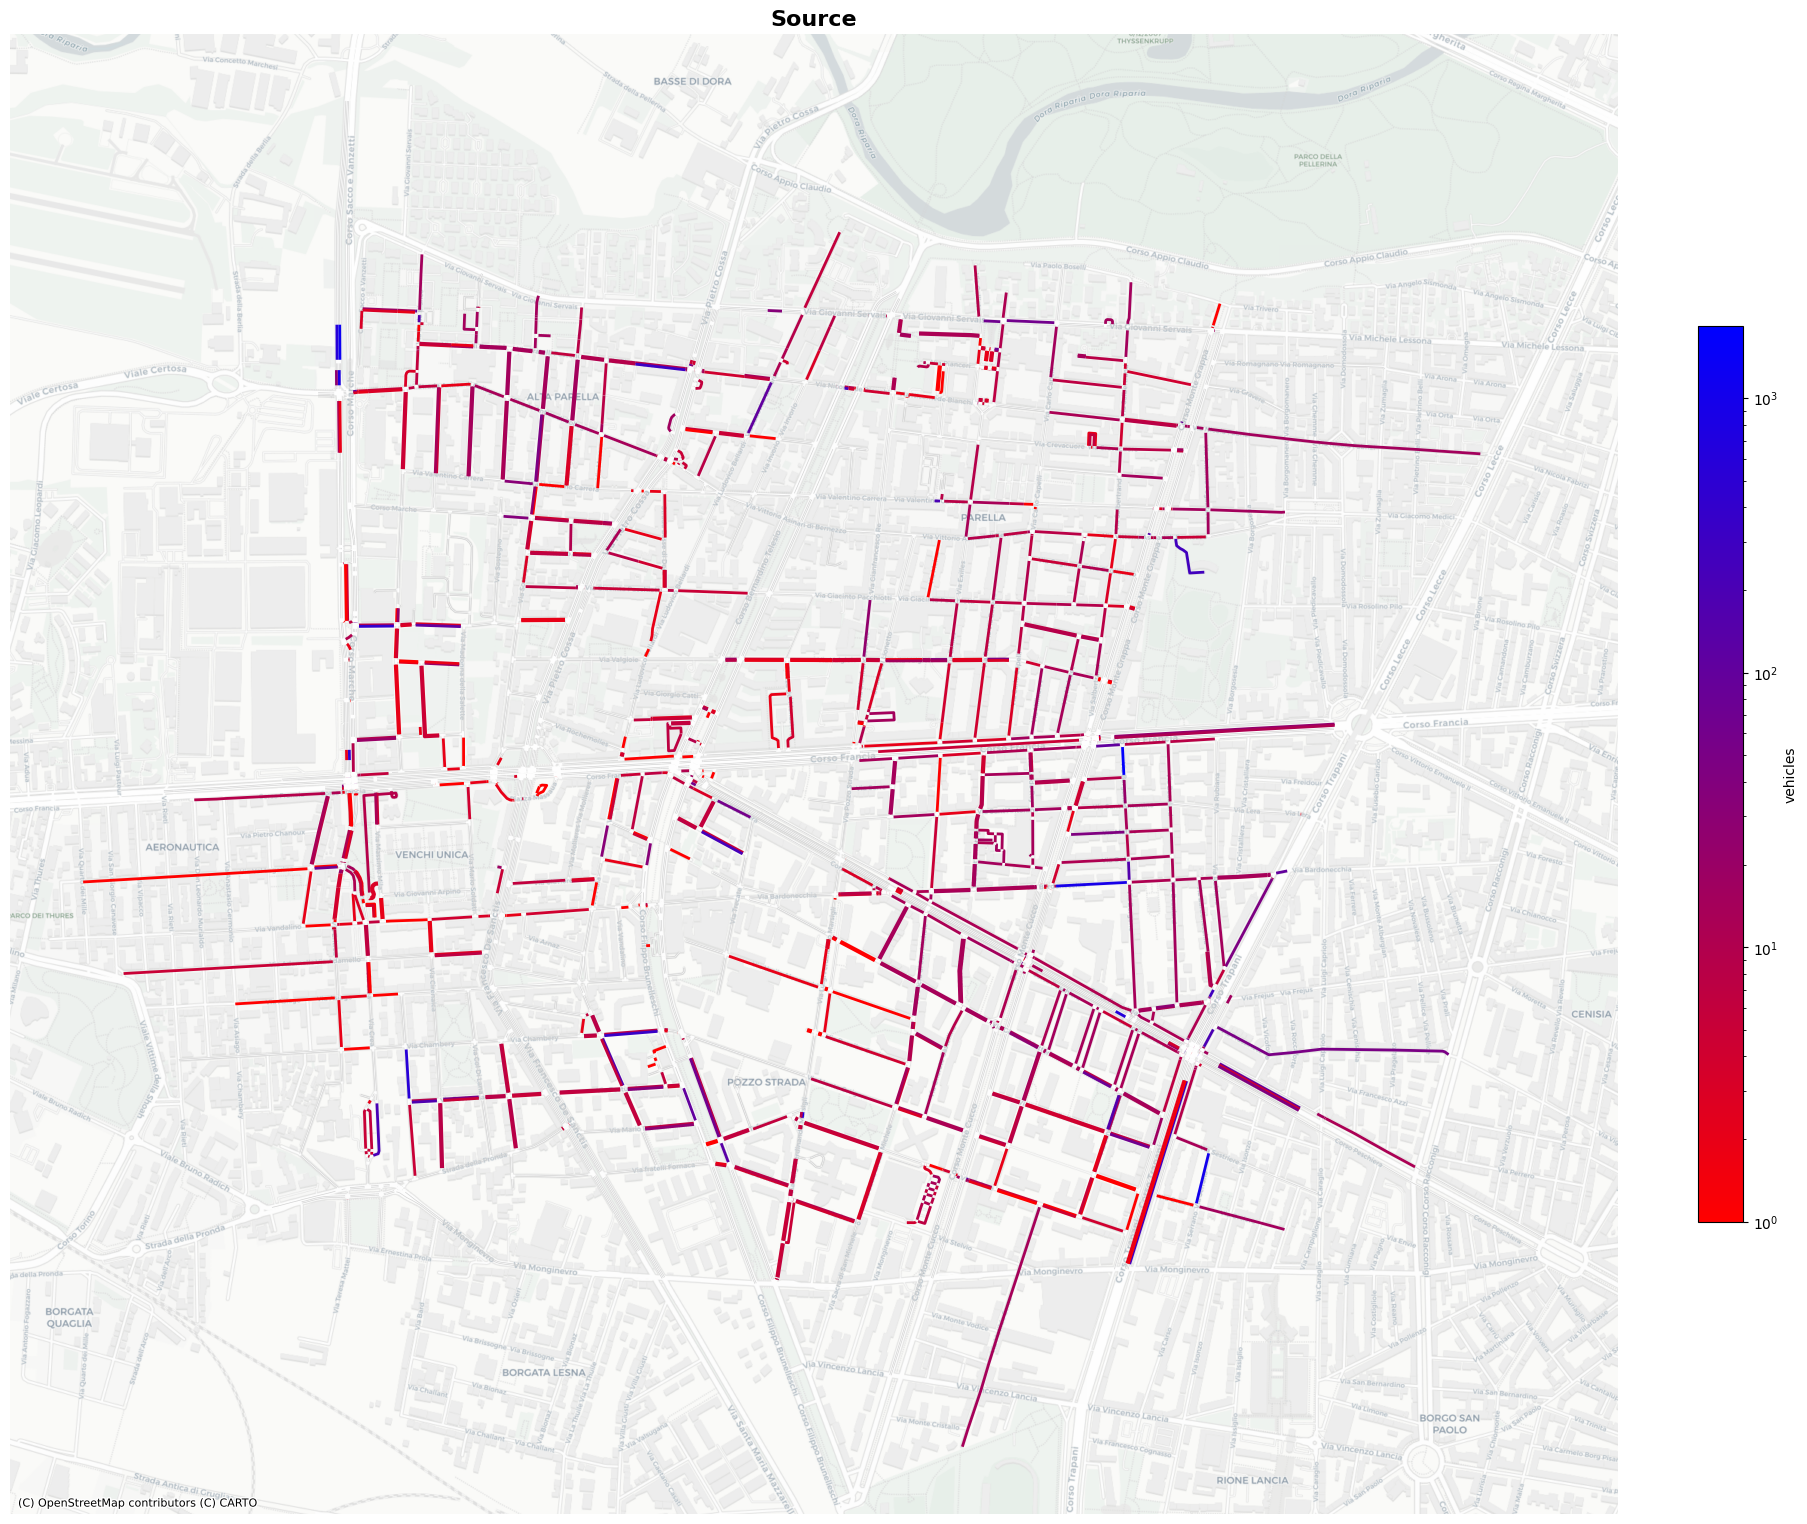

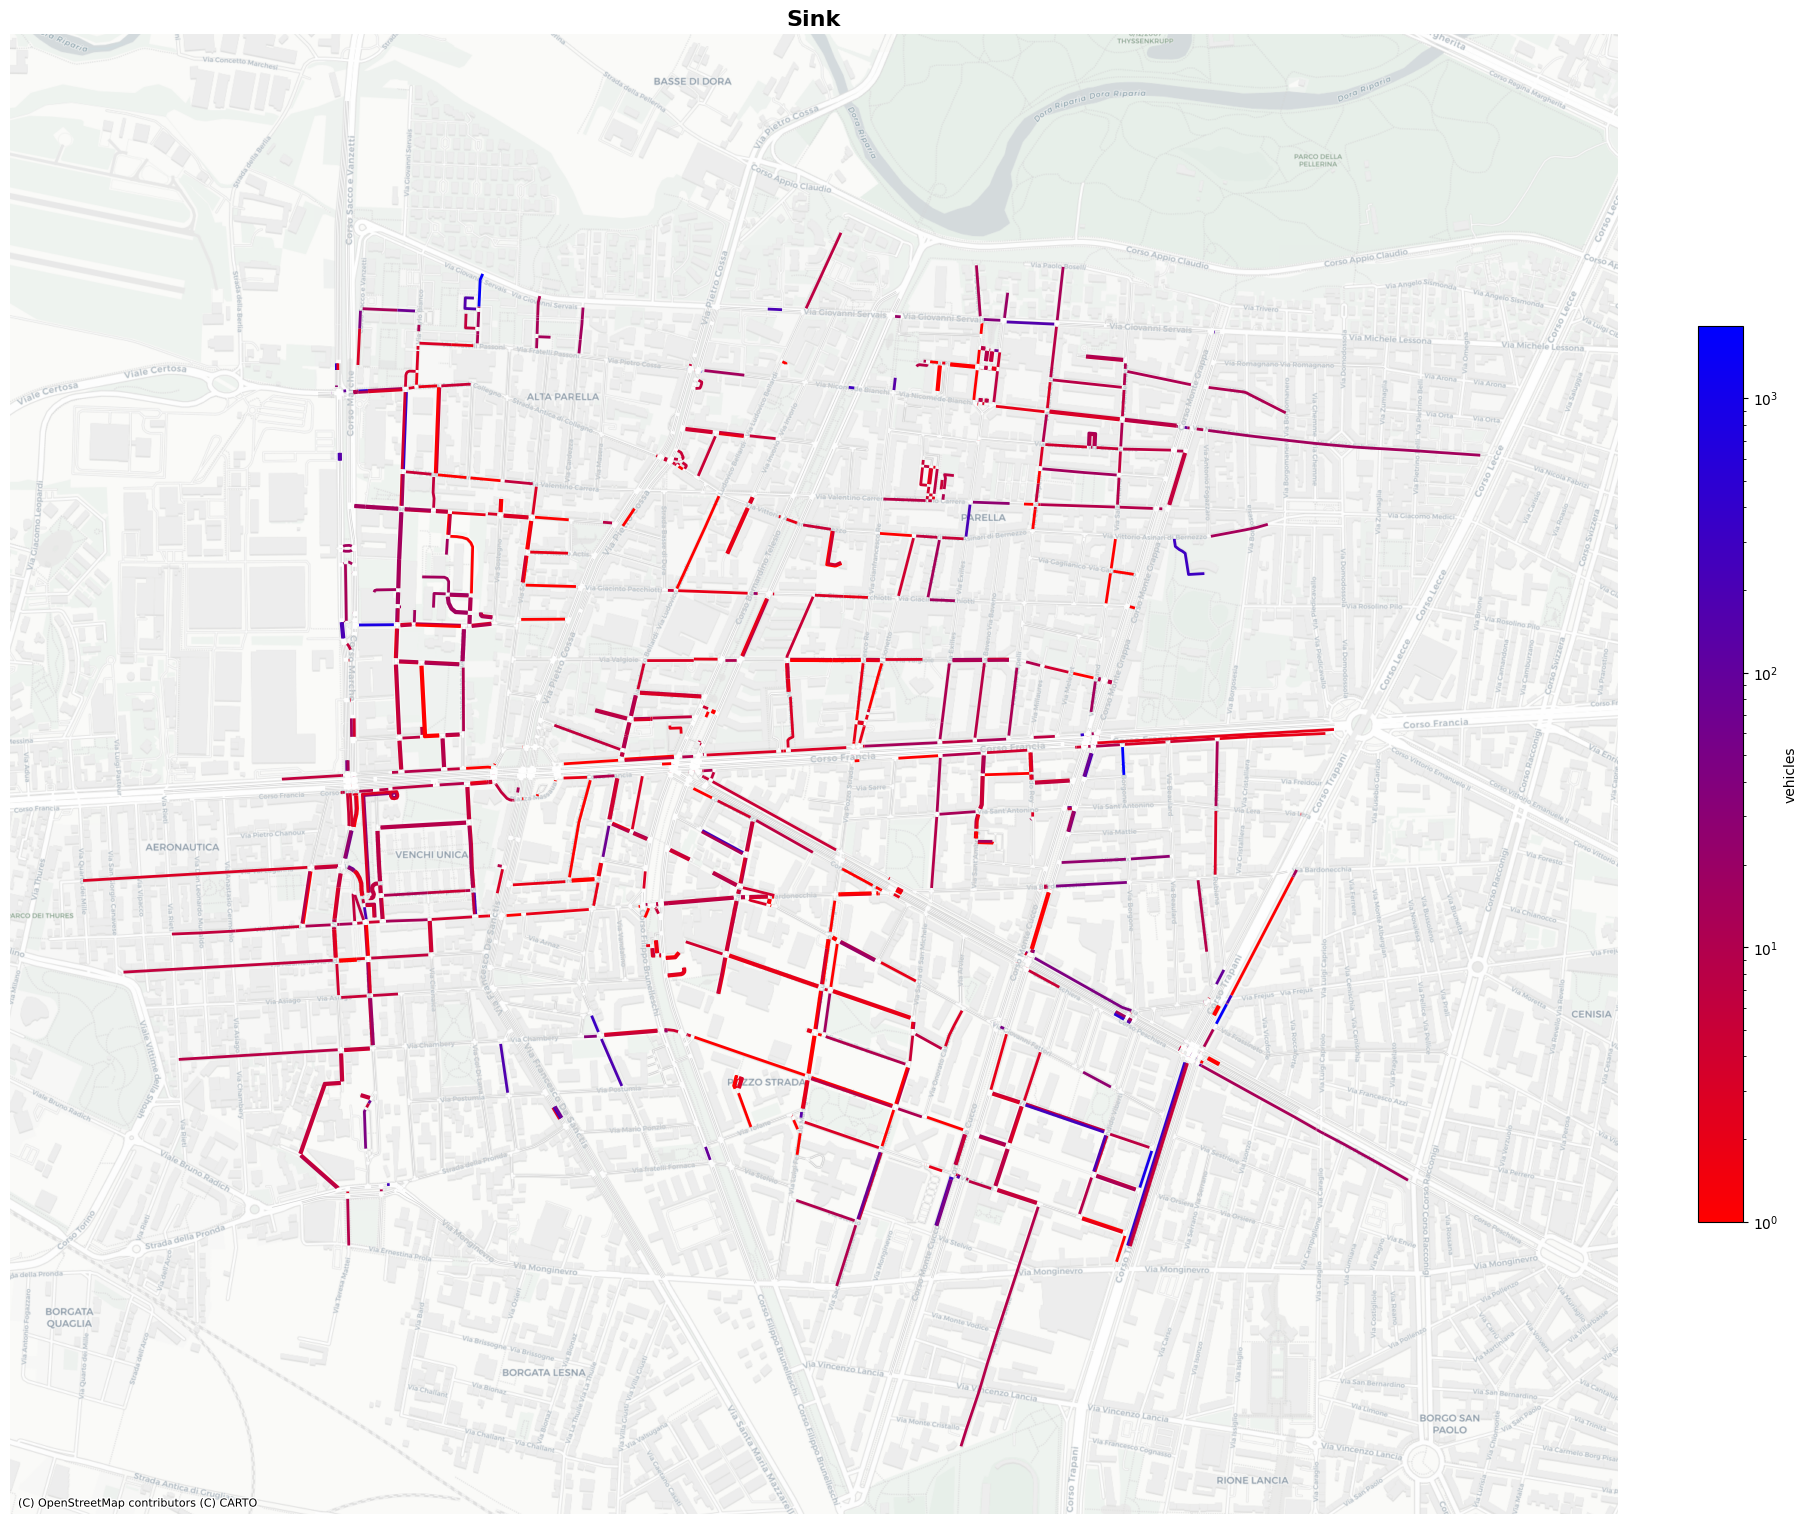

In [22]:
import matplotlib.colors as mcolors
import contextily as cx

gdf_lanes.crs = "EPSG:4326"
gdf_usage_depart.crs = "EPSG:4326"
gdf_usage_arrival.crs = "EPSG:4326"

gdf_lanes_3857 = gdf_lanes.to_crs(epsg=3857)
gdf_usage_depart_3857 = gdf_usage_depart.to_crs(epsg=3857)
gdf_usage_arrival_3857 = gdf_usage_arrival.to_crs(epsg=3857)


vmax = max(gdf_usage_depart["n_inserted"].max(), gdf_usage_arrival["n_inserted"].max())
vmin = 0

for gdf, title in zip(
        [gdf_usage_depart_3857, gdf_usage_arrival_3857], ["Source", "Sink"]
):
        fig, ax = plt.subplots(figsize=(18, 18), constrained_layout=True)
        gdf_lanes_3857.plot(ax=ax, color="lightgrey", linewidth=0.5, zorder=1)
        norm = mcolors.LogNorm(vmin=1, vmax=vmax)

        used = gdf[gdf["n_inserted"] > 0]
        used.plot(
                ax=ax,
                column="n_inserted",
                cmap=sns.blend_palette(["red", "blue"], as_cmap=True),
                norm=norm,
                linewidth=2,
                legend=True,
                zorder=2,
                legend_kwds={"label": "vehicles", "shrink": 0.5},
        )
        cx.add_basemap(
                ax=ax, source=cx.providers.CartoDB.Positron, zoom=16, zorder=0
        )
        ax.set_title(title, fontsize=16, fontweight="bold")
        ax.set_axis_off()
        ax.set_aspect("equal")

Text(0.5, 1.0, 'TimeLoss per ora di partenza')

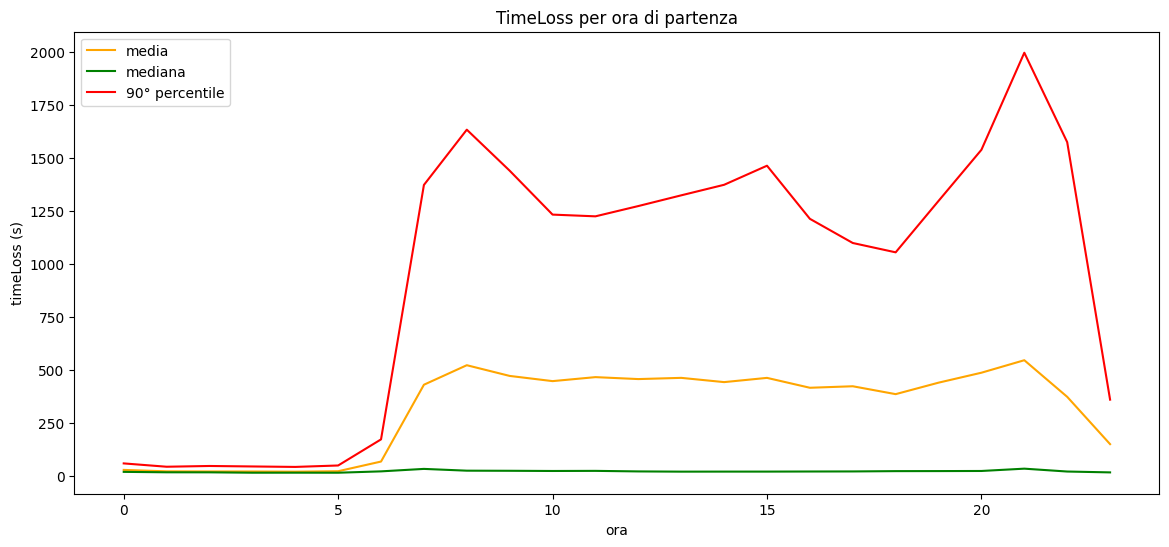

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 6))
df_res["hour"] = (df_res["depart"] // 3600).astype(int)
stats = df_res.groupby("hour")["timeLoss"].agg(["mean", "median", lambda x: x.quantile(0.9)])
stats.columns = ["mean", "median", "p90"]

ax1.plot(stats.index, stats["mean"], label="media", color="orange")
ax1.plot(stats.index, stats["median"], label="mediana", color="green")
ax1.plot(stats.index, stats["p90"], label="90° percentile", color="red")
ax1.set_xlabel("ora")
ax1.set_ylabel("timeLoss (s)")
ax1.legend()
ax1.set_title("TimeLoss per ora di partenza")